# 10. To demonstrate convolution and pooling operations in CNN using the MNIST dataset.

## Demonstrate Convolution and Pooling Operations in CNN Using the MNIST Dataset

### Aim

To demonstrate the working of Convolution and Max Pooling operations in a Convolutional Neural Network (CNN) using the MNIST handwritten digit dataset.

## Introduction

Convolutional Neural Networks (CNNs) are specialized deep learning models designed for image processing tasks. The two most important operations in CNN are **Convolution** and **Pooling**.

- **Convolution** extracts important features such as edges, lines, and textures from an image.
- **Pooling** reduces the size of the feature maps while preserving important information, making the model faster and reducing overfitting.

## Convolution Operation

The convolution layer applies multiple filters (kernels) to an input image. Each filter scans the image and generates a feature map by detecting specific patterns such as edges or shapes.

### Advantages

- Feature Extraction
- Parameter Sharing
- Reduced Computation
- Better Image Representation

## Pooling Operation

Pooling reduces the spatial dimensions of feature maps generated by the convolution layer.

The most commonly used pooling method is **Max Pooling**, which selects the maximum value from each region of the feature map.

### Advantages

- Reduces computation
- Prevents overfitting
- Preserves important features
- Improves model efficiency

## Algorithm

1. Import the required libraries.
2. Load the MNIST dataset.
3. Normalize the image.
4. Display the original image.
5. Create a convolution layer.
6. Apply convolution to the image.
7. Apply Max Pooling.
8. Display the feature maps after convolution and pooling.

In [1]:
#Import Libraries
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.models import Sequential
import numpy as np

In [2]:
# Load MNIST Dataset

(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Training Images :", X_train.shape)
print("Testing Images :", X_test.shape)

Training Images : (60000, 28, 28)
Testing Images : (10000, 28, 28)


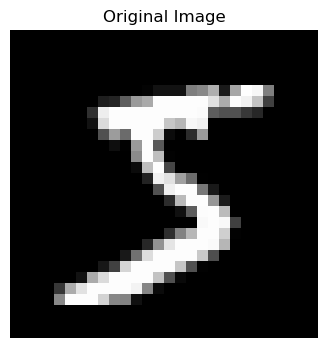

In [3]:
#Display Original Image
plt.figure(figsize=(4,4))

plt.imshow(X_train[0], cmap='gray')

plt.title("Original Image")

plt.axis('off')

plt.show()

In [4]:
#Normalize and Reshape
X_train = X_train.astype('float32') / 255.0

X_train = X_train.reshape(-1,28,28,1)

print(X_train.shape)

(60000, 28, 28, 1)


In [5]:
#Create CNN Model
model = Sequential()

model.add(Conv2D(
    filters=4,
    kernel_size=(3,3),
    activation='relu',
    input_shape=(28,28,1)
))

model.add(MaxPooling2D(pool_size=(2,2)))

C:\Users\Smit\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
#Display Model Summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 4)           │              40 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 4)           │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 40 (160.00 B)

 Trainable params: 40 (160.00 B)

 Non-trainable params: 0 (0.00 B)

In [7]:
#Apply Convolution and Pooling
feature_model = tf.keras.Model(
    inputs=model.inputs,
    outputs=[
        model.layers[0].output,
        model.layers[1].output
    ]
)

conv_output, pool_output = feature_model.predict(X_train[:1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step


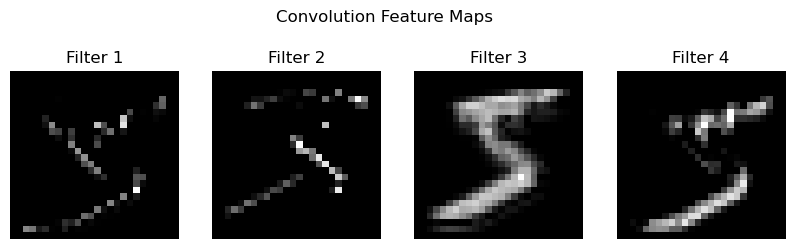

In [8]:
#Display Convolution Feature Maps
plt.figure(figsize=(10,3))

for i in range(4):
    plt.subplot(1,4,i+1)
    plt.imshow(conv_output[0,:,:,i], cmap='gray')
    plt.title(f"Filter {i+1}")
    plt.axis('off')

plt.suptitle("Convolution Feature Maps")

plt.show()

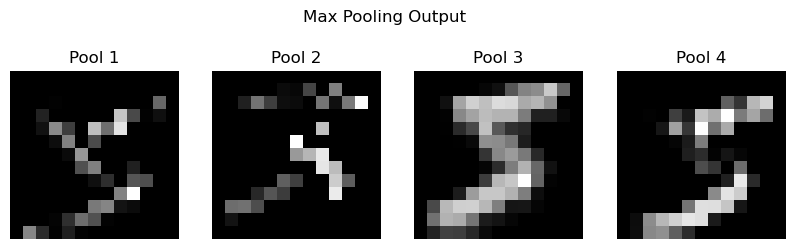

In [9]:
#Display Pooling Output
plt.figure(figsize=(10,3))

for i in range(4):
    plt.subplot(1,4,i+1)
    plt.imshow(pool_output[0,:,:,i], cmap='gray')
    plt.title(f"Pool {i+1}")
    plt.axis('off')

plt.suptitle("Max Pooling Output")

plt.show()

## Expected Output

- Original handwritten digit image.
- CNN model summary.
- Four feature maps generated after the convolution operation.
- Four feature maps after the Max Pooling operation.
- Comparison showing how pooling reduces the feature map size.

## Observation

- The convolution layer extracts important features from the handwritten digit.
- Different filters detect different image patterns.
- Max Pooling reduces the dimensions of feature maps while preserving significant information.
- Pooling makes the CNN more efficient by reducing computational complexity.

## Result

The convolution and max pooling operations of a Convolutional Neural Network (CNN) were successfully demonstrated using the MNIST dataset. The generated feature maps illustrate how convolution extracts image features and how pooling reduces the feature map dimensions while retaining important information.